# AI Coach - New Approach (Manual Labeling)

This notebook documents the new, improved approach for the AI Coach project, focusing on training a high-quality squat assessment model using manually labeled data.



In [ ]:
%pip -q install --upgrade pip
%pip -q install -r requirements.txt || true

import os
from pathlib import Path
import sys
from dotenv import load_dotenv
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import joblib
from PIL import Image
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from ai_coach.pose import PoseEstimator
from ai_coach.per_rep_features import SQUAT_REP_FEATURES
from ai_coach.coach import HybridSquatCoach

VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv'}

load_dotenv()
print('Project root:', PROJECT_ROOT)
print("Libraries imported.")



Python(50367) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


Python(50368) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.
Project root: /Users/user/MScAI_Thesis
Libraries imported.


In [ ]:


MANUAL_LABELS_CSV = Path('outputs/manual_labels.csv')

if not MANUAL_LABELS_CSV.exists():
    raise FileNotFoundError(f"'{MANUAL_LABELS_CSV}' not found. Please run the AI_Coach_Interactive_Labeler.ipynb notebook to create it.")

rep_df = pd.read_csv(MANUAL_LABELS_CSV)

rep_df.dropna(inplace=True)
    
print(f"Loaded {len(rep_df)} manually labeled reps from {MANUAL_LABELS_CSV}")
print("\nOriginal label distribution:\n", rep_df['label'].value_counts())


if not rep_df.empty:
    X = rep_df[SQUAT_REP_FEATURES].values.astype(np.float32)
    y = rep_df['label'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"\nSplit data into {len(y_train)} training samples and {len(y_test)} testing samples.")
    print("\nTraining set label distribution:\n", pd.Series(y_train).value_counts())
    print("\nTest set label distribution:\n", pd.Series(y_test).value_counts())
else:
    print("DataFrame is empty. Cannot proceed.")
    X_train, X_test, y_train, y_test = [], [], [], []



Loaded 182 manually labeled reps from outputs/manual_labels.csv

Original label distribution:
 label
good           104
bad_posture     50
too_high        17
too_low         11
Name: count, dtype: int64

Split data into 127 training samples and 55 testing samples.

Training set label distribution:
 good           72
bad_posture    35
too_high       12
too_low         8
Name: count, dtype: int64

Test set label distribution:
 good           32
bad_posture    15
too_high        5
too_low         3
Name: count, dtype: int64


In [ ]:
if 'X_train' in locals() and len(X_train) > 0:
    min_class_count = pd.Series(y_train).value_counts().min()
    k_neighbors = max(1, min_class_count - 1)
    
    print(f"\nSmallest class in training set has {min_class_count} samples. Setting k_neighbors for SMOTE to {k_neighbors}.")
    
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print("\nTraining set distribution after SMOTE:\n", pd.Series(y_train_resampled).value_counts())
else:
    print("Skipping SMOTE application because training data is not available.")
    X_train_resampled, y_train_resampled = X_train, y_train




Smallest class in training set has 8 samples. Setting k_neighbors for SMOTE to 7.

Training set distribution after SMOTE:
 good           72
bad_posture    72
too_high       72
too_low        72
Name: count, dtype: int64


Python(50372) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Training on 288 resampled samples...
Evaluating on 55 original test samples.

Accuracy: 0.6181818181818182

Classification Report (on test set):
               precision    recall  f1-score   support

 bad_posture       0.50      0.33      0.40        15
        good       0.77      0.75      0.76        32
    too_high       0.43      0.60      0.50         5
     too_low       0.29      0.67      0.40         3

    accuracy                           0.62        55
   macro avg       0.50      0.59      0.52        55
weighted avg       0.64      0.62      0.62        55



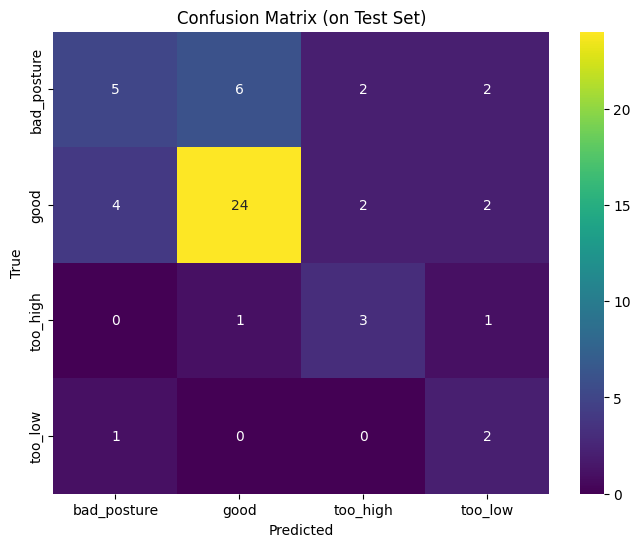

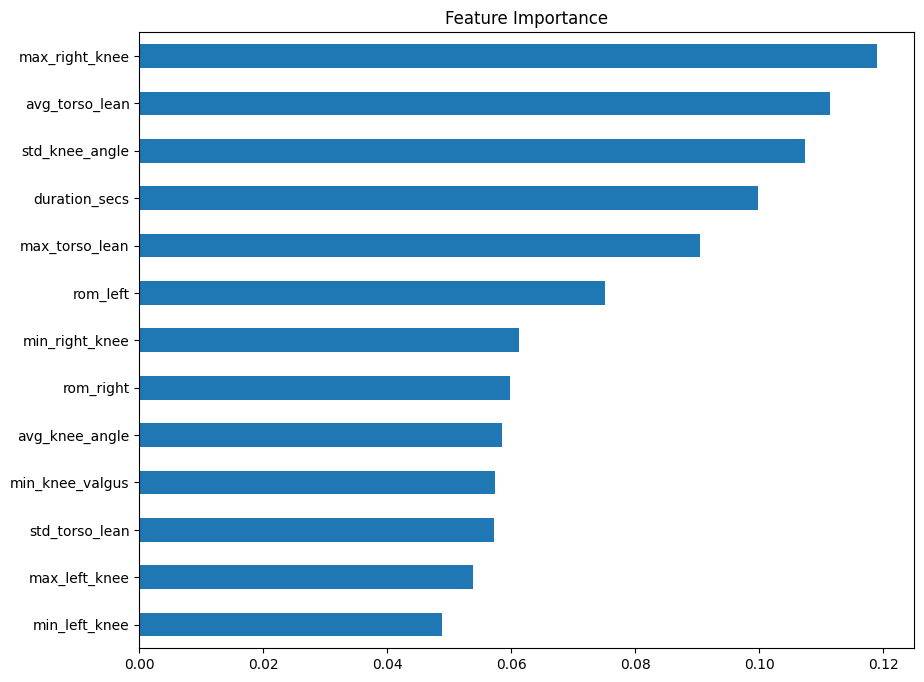


Saved new model to models/squat_quality_multiclass.joblib


In [ ]:
if 'X_train_resampled' in locals() and len(X_train_resampled) > 0:
    
    models_to_tune = {
        "RandomForest": {
            "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "params": {
                'n_estimators': [100, 200],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
            }
        },
        "XGBoost": {
            "model": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
            "params": {
                'n_estimators': [100, 200],
                'max_depth': [5, 7, 10],
                'learning_rate': [0.1, 0.2],
                'gamma': [0, 0.1]
            }
        }
    }

    results_log = {}
    best_estimators = {}

    for name, config in models_to_tune.items():
        print(f"\n--- Tuning {name} ---")
        grid_search = GridSearchCV(estimator=config["model"], param_grid=config["params"], 
                                   cv=3, n_jobs=-1, verbose=2, scoring='accuracy')
        
        grid_search.fit(X_train_resampled, y_train_resampled)
        
        best_model = grid_search.best_estimator_
        best_estimators[name] = best_model
        
        y_pred = best_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        results_log[name] = {'accuracy': accuracy, 'best_params': grid_search.best_params_}
        print(f"--- Finished Tuning {name}. Test Accuracy: {accuracy:.4f} ---")

    best_model_name = max(results_log, key=lambda name: results_log[name]['accuracy'])
    champion_model = best_estimators[best_model_name]
    champion_accuracy = results_log[best_model_name]['accuracy']

    summary_df = pd.DataFrame(results_log).T.sort_values(by='accuracy', ascending=False)
    display(Markdown("### Model Comparison Results"))
    display(summary_df)
    
    print(f"\n🏆 Champion Model: {best_model_name} with Test Accuracy: {champion_accuracy:.4f}")

    y_pred_champion = champion_model.predict(X_test)
    labels_sorted = sorted(rep_df['label'].unique())
    print("\nClassification Report (Champion Model):\n", classification_report(y_test, y_pred_champion, labels=labels_sorted, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred_champion, labels=labels_sorted)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_sorted, yticklabels=labels_sorted, cmap='viridis')
    plt.title(f'Confusion Matrix for Champion: {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    if hasattr(champion_model, 'feature_importances_'):
        importances = champion_model.feature_importances_
        plt.figure(figsize=(10, 8))
        feat_series = pd.Series(importances, index=SQUAT_REP_FEATURES).sort_values()
        feat_series.plot(kind='barh')
        plt.title(f'Feature Importance ({best_model_name})')
        plt.show()
    
    Path('models').mkdir(exist_ok=True)
    joblib.dump(champion_model, 'models/squat_quality_multiclass.joblib')
    print(f"\nSaved champion model ({best_model_name}) to models/squat_quality_multiclass.joblib")
else:
    print("No data available; skipping training.")



In [ ]:
if 'champion_model' in locals():
    X_test_df = pd.DataFrame(X_test, columns=SQUAT_REP_FEATURES)
    
    misclassified_mask = y_pred_champion != y_test
    misclassified_indices = np.where(misclassified_mask)[0]
    
    if len(misclassified_indices) > 0:
        print(f"The champion model ({best_model_name}) misclassified {len(misclassified_indices)} out of {len(y_test)} test samples.\n")
        
        error_df = X_test_df.iloc[misclassified_indices].copy()
        error_df['True Label'] = y_test[misclassified_mask]
        error_df['Predicted Label'] = y_pred_champion[misclassified_mask]
        
        cols = ['True Label', 'Predicted Label'] + [col for col in error_df.columns if col not in ['True Label', 'Predicted Label']]
        error_df = error_df[cols]
        
        display(Markdown("#### Analysis of Misclassified Reps"))
        with pd.option_context('display.max_rows', 200, 'display.max_columns', 20):
            display(error_df)
    else:
        print("🎉🎉🎉 Amazing! The champion model had 0 misclassifications on the test set!")
else:
    print("Champion model not found. Please run the training cell above first.")

Found 3 videos to process in 'test_video'.

--- Processing test video: squat_8.mp4 ---


I0000 00:00:1755179978.636502 5560978 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755179978.750416 5668890 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755179978.770675 5668894 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing complete. Annotated video saved to: outputs/inference_manual_squat_8.mp4

--- Processing test video: videoplayback (1).mov ---


I0000 00:00:1755179981.418803 5560978 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755179981.492887 5668954 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755179981.507129 5668960 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing complete. Annotated video saved to: outputs/inference_manual_videoplayback (1).mp4

--- Processing test video: videoplayback.mov ---


I0000 00:00:1755180017.160345 5560978 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755180017.243948 5669301 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755180017.260658 5669303 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing complete. Annotated video saved to: outputs/inference_manual_videoplayback.mp4


--- Inference Previews ---

Preview for: squat_8.mp4


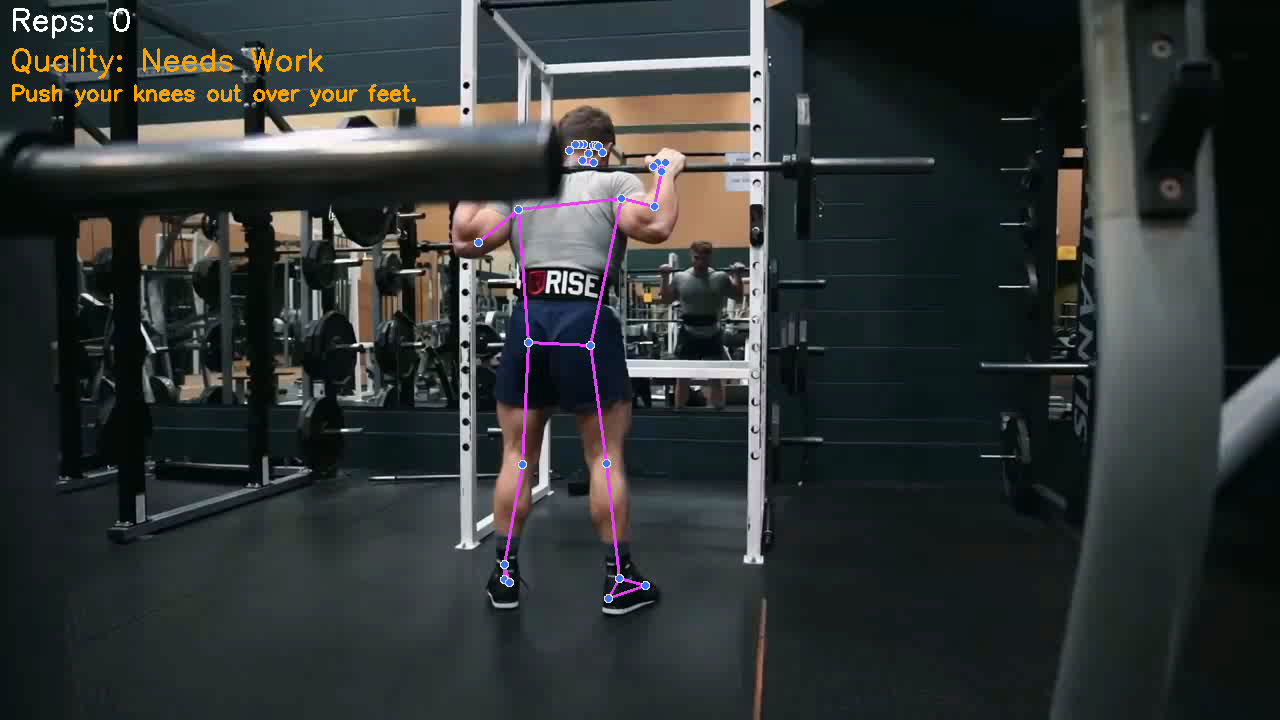


Preview for: videoplayback (1).mov


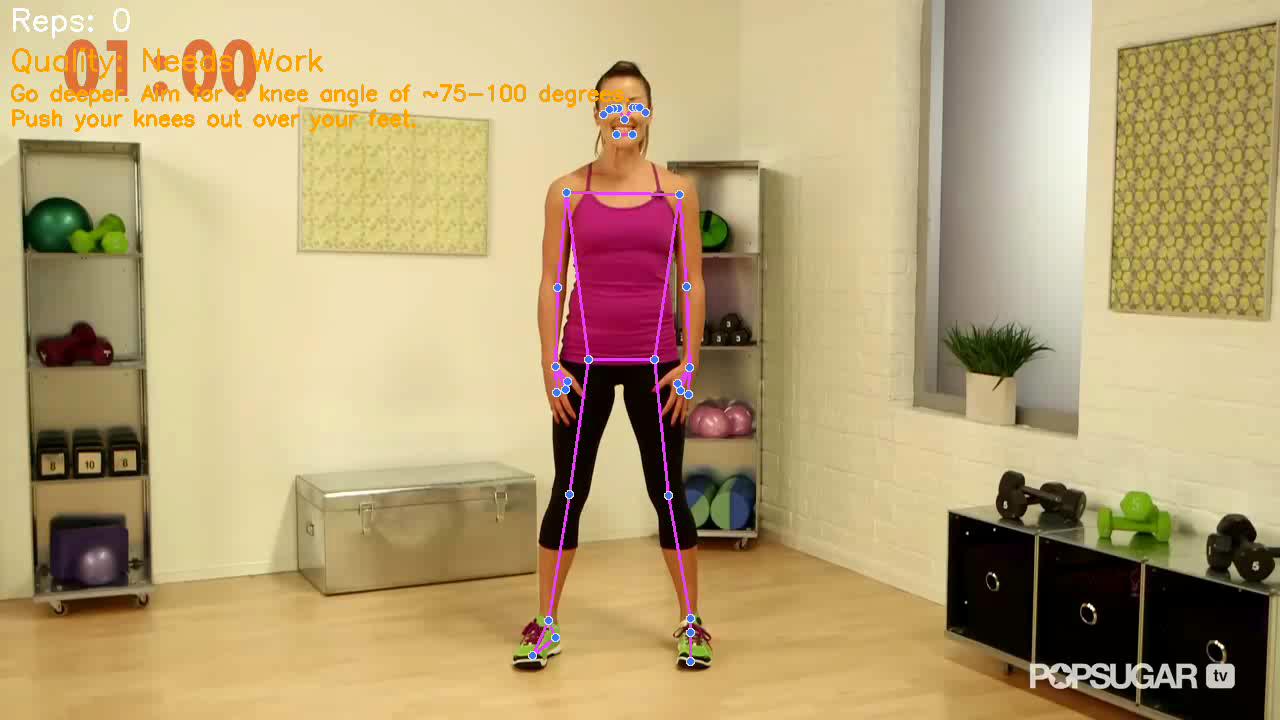


Preview for: videoplayback.mov


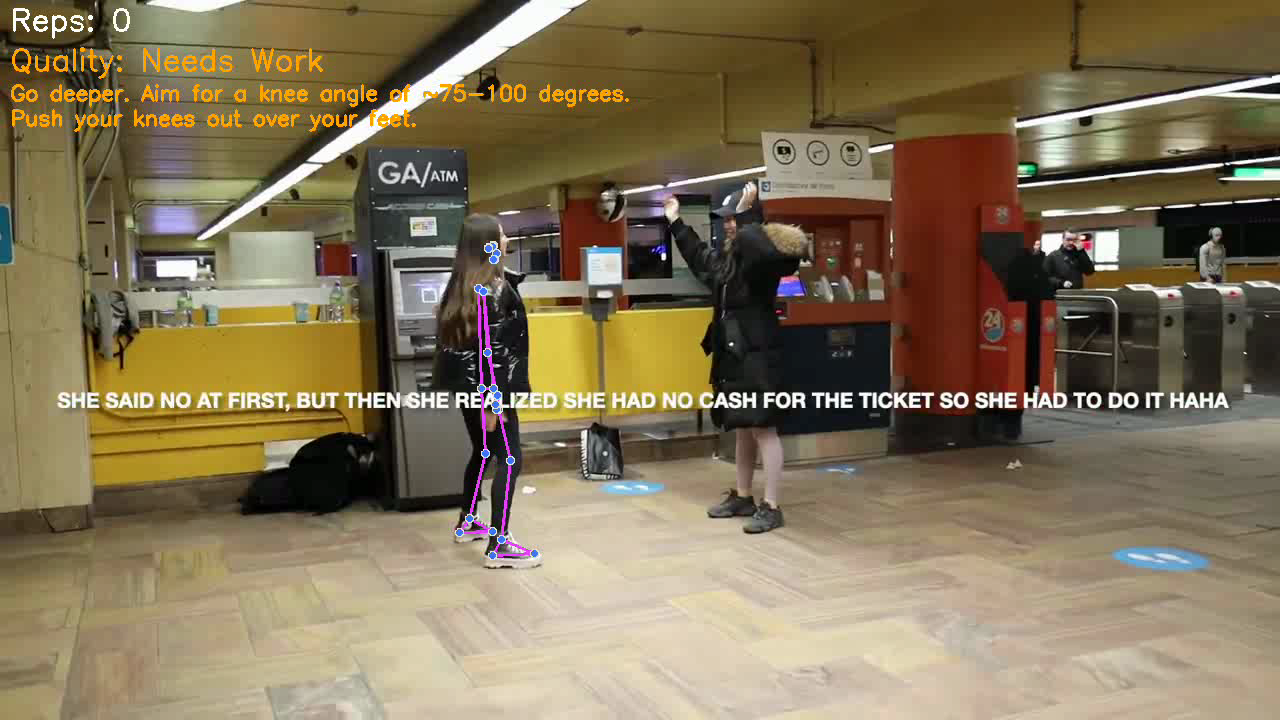

In [ ]:
def ensure_even_size(w, h):
    return (w - (w % 2), h - (w % 2))

TEST_VIDEO_DIR = Path('test_video')
test_videos = [p for p in TEST_VIDEO_DIR.rglob('*') if p.suffix.lower() in VIDEO_EXTS]

if not test_videos:
    print(f"No videos found in {TEST_VIDEO_DIR}. Please add a video to test the pipeline.")
else:
    print(f"Found {len(test_videos)} videos to process in '{TEST_VIDEO_DIR}'.")
    all_previews = []

    for sample_video in test_videos:
        print(f"\n--- Processing test video: {sample_video.name} ---")
        cap = cv2.VideoCapture(str(sample_video))
        if not cap.isOpened():
            print(f"Failed to open video: {sample_video.name}")
            continue

        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        w, h = ensure_even_size(w, h)
        out_dir = Path('outputs')
        out_path = out_dir / f"inference_manual_{sample_video.stem}.mp4"
        writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
        
        coach = HybridSquatCoach(model_path='models/squat_quality_multiclass.joblib')
        
        pose = PoseEstimator()
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_LINEAR)
            results_pose, image = pose.process(frame)
            if results_pose.pose_landmarks is None:
                if writer: writer.write(image)
                continue
            ui = coach.update(results_pose.pose_landmarks.landmark)
            
            rep_count_text = f'Reps: {ui["rep_count"]}'
            quality_text = ui["display_quality"]
            recs_text = ui["display_recs"]
            color = ui["display_color"]
            cv2.putText(image, rep_count_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.putText(image, quality_text, (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
            y0 = 100
            for rec in recs_text:
                cv2.putText(image, rec, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
                y0 += 25
            PoseEstimator.draw_landmarks(image, results_pose.pose_landmarks)
            if writer: writer.write(image)
        
        pose.close()
        cap.release()
        if writer: writer.release()
        print(f"Processing complete. Annotated video saved to: {out_path}")
        
        cap = cv2.VideoCapture(str(out_path))
        ret, frame = cap.read()
        if ret:
            all_previews.append((sample_video.name, Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))))
        cap.release()

    print("\n\n--- Inference Previews ---")
    for name, img in all_previews:
        print(f"\nPreview for: {name}")
        display(img)